In [1]:
import pandas as pd
import numpy as np

cpu_df = pd.read_csv(
    "../data/Processed/cpu_cleaned.csv"
)

cpu_df["ts"] = pd.to_datetime(
    cpu_df["ts"],
    format="mixed",
    utc=True
)

In [2]:
# Sort data (for time series analysis)
cpu_df = cpu_df.sort_values(
    ["hostName", "ts"]
)

cpu_df = cpu_df.reset_index(drop=True)

### CPU Features

In [3]:
# Lag features for CPU Usage data
# CPU Lag 1 - CPU 5 minutes ago
cpu_df["cpu_lag_1"] = (
    cpu_df
    .groupby("hostName")["cpu_usage_pct"]
    .shift(1)
)
# CPU Lag 2 - CPU 10 minutes ago
cpu_df["cpu_lag_2"] = (
    cpu_df
    .groupby("hostName")["cpu_usage_pct"]
    .shift(2)
)

In [4]:
# CPU Change
cpu_df["cpu_change"] = (
    cpu_df
    .groupby("hostName")["cpu_usage_pct"]
    .diff()
)
# Current CPU - Previous CPU

In [5]:
# CPU Rolling Mean (15-min average)
# Takes the average of the last 3 values: smoothened trend -> overall trend of CPU usage
cpu_df["cpu_roll_mean_3"] = (
    cpu_df
    .groupby("hostName")["cpu_usage_pct"]
    .transform(
        lambda x: x.rolling(3).mean()
    )
)

In [6]:
# CPU Acceleration 
# Acceleration reveals overload developing.
cpu_df["cpu_acceleration"] = (
    cpu_df
    .groupby("hostName")["cpu_change"]
    .diff()
)

In [7]:
# CPU Volatility - workload instability
# takes last 12 cpu usage values -> calculates their standard deviation -> how much CPU is fluctuating
cpu_df["cpu_volatility"] = (
    cpu_df
    .groupby("hostName")["cpu_usage_pct"]
    .transform(
        lambda x: x.rolling(12).std()
    )
)

### Memory Features

In [8]:
# Memory Lag
# stores previous memory usage value -> detects if high memory usage is followed by high CPU usage
cpu_df["memory_lag_1"] = (
    cpu_df
    .groupby("hostName")["memory_usage_pct"]
    .shift(1)
)

In [9]:
# # Memory Change
# # memory_change = current - previous
# cpu_df["memory_change"] = (
#     cpu_df
#     .groupby("hostName")["memory_usage_pct"]
#     .diff()
# )

In [10]:
# CPU-to-memory ratio - for workload imbalance detection
cpu_df["cpu_memory_ratio"] = (
    cpu_df["cpu_usage_pct"]
    /
    (cpu_df["memory_usage_pct"] + 1)
)

### Power Features

In [11]:
# Power change
# power_change = current power − previous power
# cpu_df["power_change"] = (
#     cpu_df
#     .groupby("hostName")["power_kw"]
#     .diff()
# )

In [12]:
# Power Rolling Mean 
# Computes average power over last 12 time steps
cpu_df["power_roll_mean_12"] = (
    cpu_df
    .groupby("hostName")["power_kw"]
    .transform(
        lambda x: x.rolling(12).mean()
    )
)

### Thermal Gradient

In [13]:
# thermal gradient
cpu_df["thermal_gradient"] = (
    cpu_df["cpu_temp_c"]
    -
    cpu_df["inlet_temp_c"]
)
# Inlet temperature = the temperature of the air entering the server (before cooling the CPU)
# thermal gradient = How much the CPU is heating up above ambient temperature
# Same CPU temp, different meanings depending on cooling conditions

# High gradient → CPU generating lots of heat ⚠️
# Low gradient → environment already hot

In [14]:
# CPU temperature rate of change - for thermal anomaly detection
cpu_df["temp_rate_of_change"] = (
    cpu_df
    .groupby("hostName")["cpu_temp_c"]
    .diff()
)

In [15]:
# temperature rolling mean
cpu_df["temp_roll_mean_12"] = (
    cpu_df
    .groupby("hostName")["cpu_temp_c"]
    .transform(
        lambda x: x.rolling(12).mean()
    )
)

### Efficiency Features

In [16]:
# CPU Usage per kW
# cpu_per_kw = CPU usage / power consumed
# “How much useful CPU work am I getting per unit of power?”

cpu_df["cpu_per_kw"] = (
    cpu_df["cpu_usage_pct"]
    /
    cpu_df["power_kw"]
)
# high value - efficient
# low value - possible inefficiency

In [17]:
# Temperature per CPU
cpu_df["temp_per_cpu"] = (
    cpu_df["cpu_temp_c"]
    /
    (cpu_df["cpu_usage_pct"] + 1)
)
# for e.g: if CPU=20% and temp=70% -> suspicious

In [18]:
# Verify features
cpu_df.head()

,id,ts,host_id,cpu_usage_pct,memory_usage_pct,power_kw,status,hostName,inlet_temp_c,cpu_temp_c,...,cpu_acceleration,cpu_volatility,memory_lag_1,cpu_memory_ratio,power_roll_mean_12,thermal_gradient,temp_rate_of_change,temp_roll_mean_12,cpu_per_kw,temp_per_cpu
0,2,2026-04-02 12:22:07.517000+00:00,2,17.0,70.0,0.245,Normal,10.10.10.150,20,43,...,NaN,NaN,NaN,0.239437,NaN,23,NaN,NaN,69.387755,2.388889
1,5,2026-04-02 12:24:02.882000+00:00,2,16.0,70.0,0.263,Normal,10.10.10.150,20,44,...,NaN,NaN,70.0,0.225352,NaN,24,1.0,NaN,60.836502,2.588235
2,8,2026-04-02 12:26:01.700000+00:00,2,15.0,70.0,0.256,Normal,10.10.10.150,21,44,...,0.0,NaN,70.0,0.211268,NaN,23,0.0,NaN,58.593750,2.750000
3,11,2026-04-02 12:28:01.845000+00:00,2,16.0,70.0,0.251,Normal,10.10.10.150,20,44,...,2.0,NaN,70.0,0.225352,NaN,24,0.0,NaN,63.745020,2.588235
4,14,2026-04-02 12:30:02.091000+00:00,2,16.0,70.0,0.260,Normal,10.10.10.150,20,45,...,-1.0,NaN,70.0,0.225352,NaN,25,1.0,NaN,61.538462,2.647059


In [19]:
# # CPU Utilisation per core
# cpu_df["cpu_per_processor"] = (
#     cpu_df["cpu_usage_pct"]
#     /
#     cpu_df["processor_count"]
# )

In [20]:
# # Power per processor
# cpu_df["power_per_processor"] = (
#     cpu_df["power_kw"]
#     /
#     cpu_df["processor_count"]
# )

In [21]:
# # Thermal Load index
# # combines CPU Workload and thermal stress
# cpu_df["thermal_load_index"] = (
#     cpu_df["cpu_usage_pct"]
#     *
#     (
#         cpu_df["cpu_temp_c"]
#         -
#         cpu_df["inlet_temp_c"]
#     )
# )

In [22]:
# Resource Stress Index
# CPU issues are often accompanied by memory pressure.
cpu_df["resource_stress_index"] = (
    cpu_df["cpu_usage_pct"]
    +
    cpu_df["memory_usage_pct"]
) / 2

In [23]:
# Thermal efficiency index
# Detects abnormal heating relative to power consumption.
# cpu_df["thermal_efficiency_index"] = (
#     cpu_df["cpu_temp_c"]
#     /
#     cpu_df["power_kw"]
# )

In [24]:
# Check for missing values (expected due to lag features)
cpu_df.isnull().sum()

id                        0
ts                        0
host_id                   0
cpu_usage_pct             0
memory_usage_pct          0
power_kw                  0
status                    0
hostName                  0
inlet_temp_c              0
cpu_temp_c                0
processor_count           0
status_encoded            0
cpu_lag_1                 3
cpu_lag_2                 6
cpu_change                3
cpu_roll_mean_3           6
cpu_acceleration          6
cpu_volatility           33
memory_lag_1              3
cpu_memory_ratio          0
power_roll_mean_12       33
thermal_gradient          0
temp_rate_of_change       3
temp_roll_mean_12        33
cpu_per_kw                0
temp_per_cpu              0
resource_stress_index     0
dtype: int64

In [25]:
# Remove initial NaNs
cpu_df = cpu_df.dropna()

In [26]:
# Save
cpu_df.to_csv(
    "../data/Processed/cpu_features.csv",
    index=False
)

### Plotting

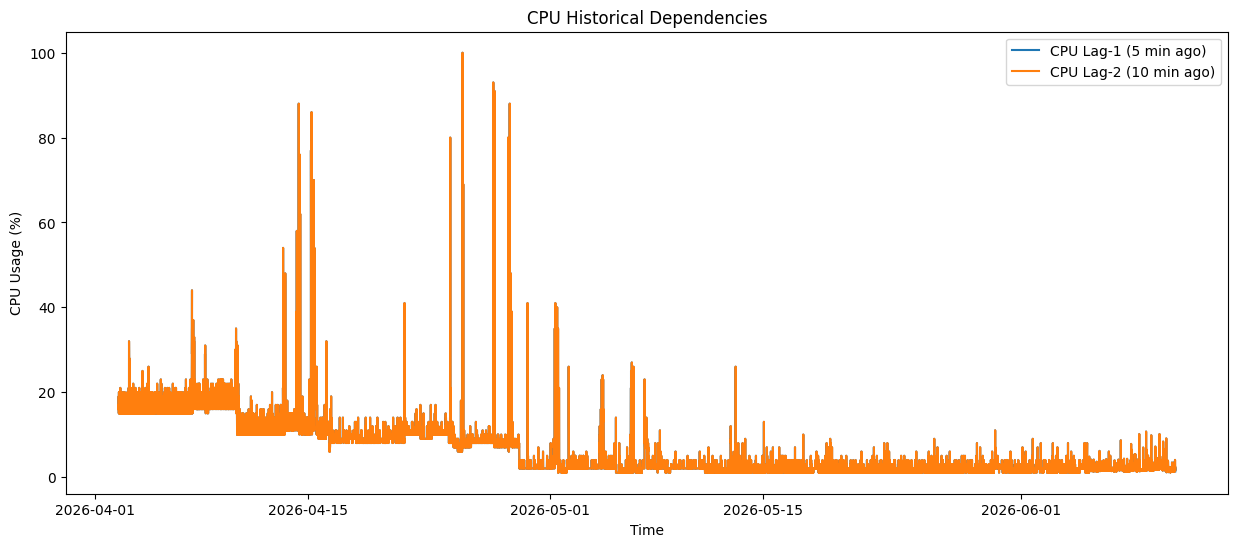

In [27]:
# CPU Lag1 and CPU Lag 2
# Compare current CPU behavior with previous CPU states.
# Demonstrates temporal dependency.
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))

server = cpu_df["hostName"].unique()[0]

temp = cpu_df[
    cpu_df["hostName"] == server
]

plt.plot(
    temp["ts"],
    temp["cpu_lag_1"],
    label="CPU Lag-1 (5 min ago)"
)

plt.plot(
    temp["ts"],
    temp["cpu_lag_2"],
    label="CPU Lag-2 (10 min ago)"
)

plt.title("CPU Historical Dependencies")
plt.xlabel("Time")
plt.ylabel("CPU Usage (%)")
plt.legend()

plt.show()

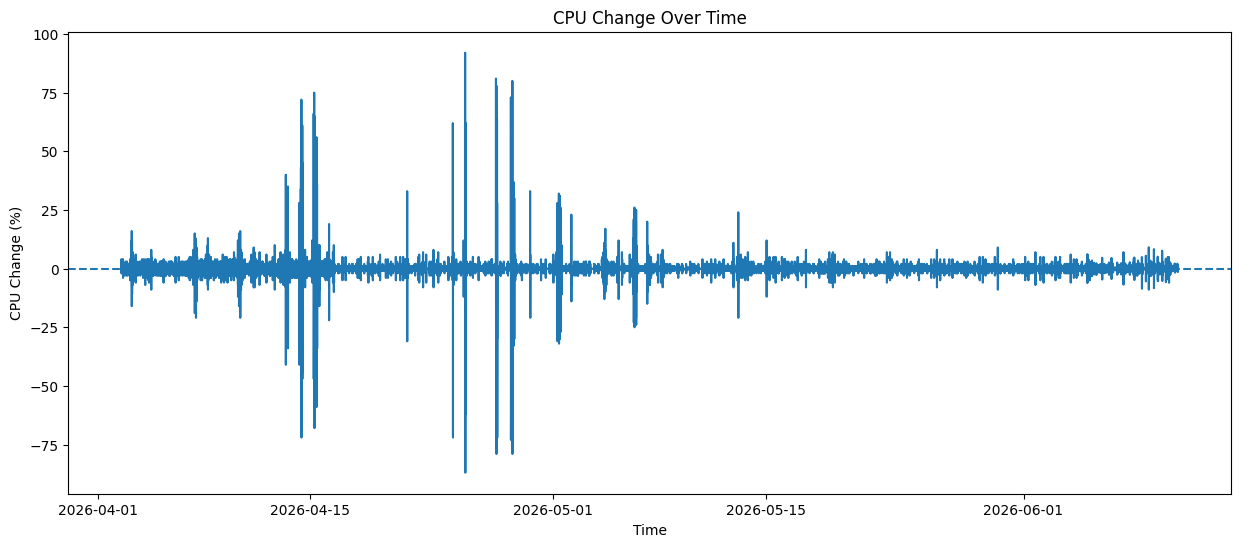

In [ ]:
# CPU Change 
# Visualize sudden workload increases/decreases.
# Useful for anomaly detection.
plt.figure(figsize=(15,6))

plt.plot(
    temp["ts"],
    temp["cpu_change"]
)

plt.title("CPU Change Over Time")
plt.xlabel("Time")
plt.ylabel("CPU Change (%)")

plt.axhline(
    y=0,
    linestyle="--"
)

plt.show()

# Positive Peaks  -> CPU spike
# Negative Peaks  -> CPU drop

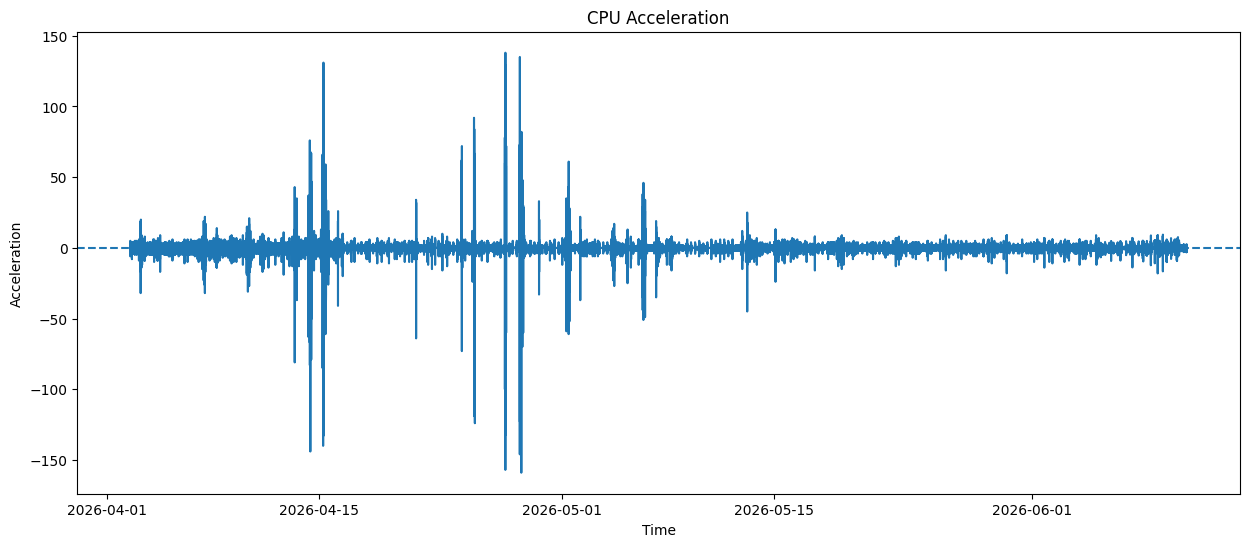

In [29]:
# CPU Acceleraion
# Detect rapidly increasing processor demand
plt.figure(figsize=(15,6))

plt.plot(
    temp["ts"],
    temp["cpu_acceleration"]
)

plt.title("CPU Acceleration")
plt.xlabel("Time")
plt.ylabel("Acceleration")

plt.axhline(
    y=0,
    linestyle="--"
)

plt.show()
# Large positive acceleration = Potential overload building up

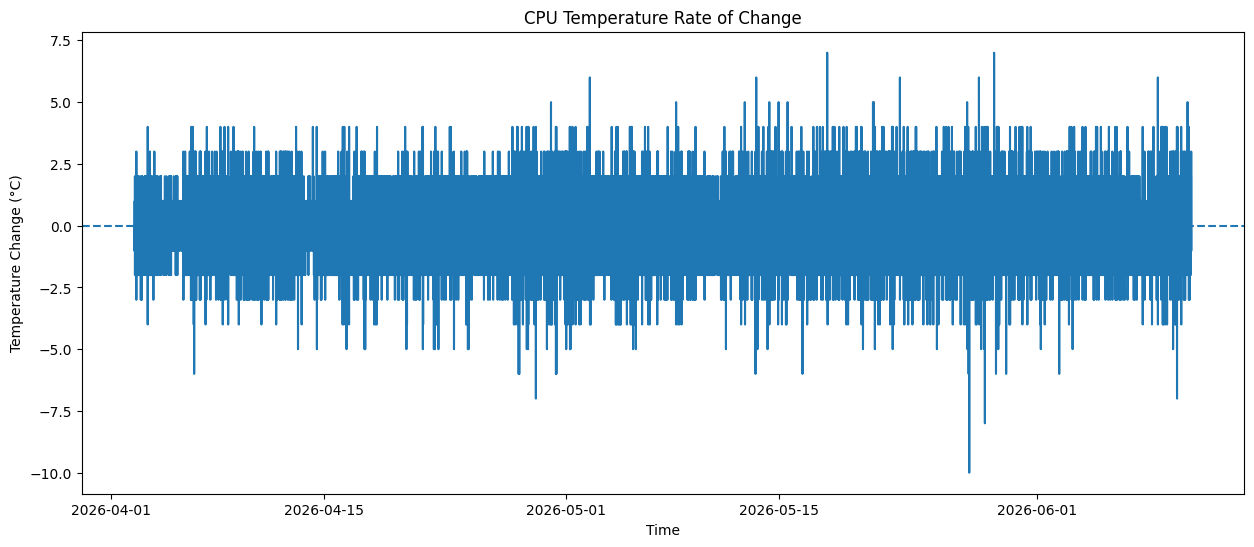

In [30]:
# CPU Temperature rate of change
# Detect rapid heating
plt.figure(figsize=(15,6))

plt.plot(
    temp["ts"],
    temp["temp_rate_of_change"]
)

plt.title("CPU Temperature Rate of Change")
plt.xlabel("Time")
plt.ylabel("Temperature Change (°C)")

plt.axhline(
    y=0,
    linestyle="--"
)

plt.show()

# Large Positive Values = Rapid Heating
# Large Negative Values = Rapid Cooling

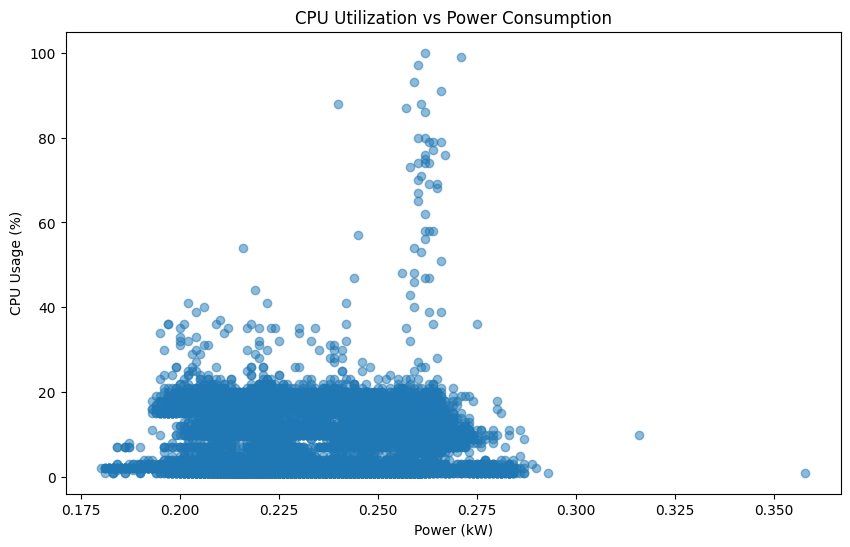

In [ ]:
# CPU Usage per kW
plt.figure(figsize=(10,6))

plt.scatter(
    temp["power_kw"],
    temp["cpu_usage_pct"],
    alpha=0.5
)

plt.title("CPU Utilization vs Power Consumption")
plt.xlabel("Power (kW)")
plt.ylabel("CPU Usage (%)")

plt.show()

# Upper Left = High CPU, Low Power = Efficient
# Lower Right = Low CPU, High Power =Inefficient

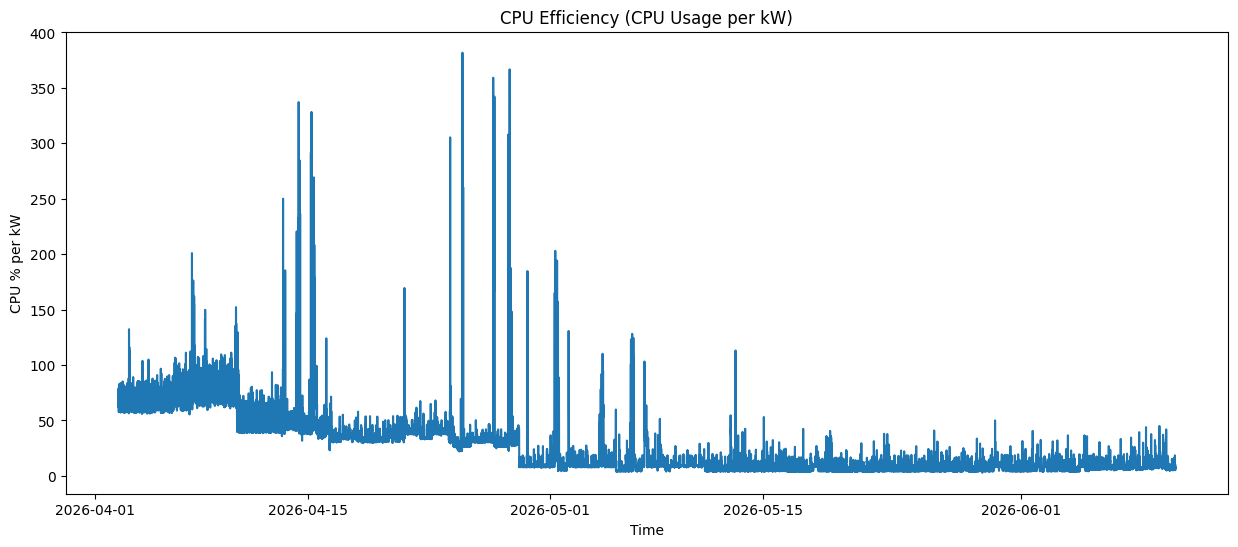

In [32]:
# CPU Efficency Plot
plt.figure(figsize=(15,6))

plt.plot(
    temp["ts"],
    temp["cpu_per_kw"]
)

plt.title("CPU Efficiency (CPU Usage per kW)")
plt.xlabel("Time")
plt.ylabel("CPU % per kW")

plt.show()